In [15]:
%pip install pandas scikit-learn catboost xgboost seaborn matplotlib joblib sentence-transformers faiss-cpu torch

Note: you may need to restart the kernel to use updated packages.


In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics.pairwise import cosine_similarity
from catboost import CatBoostRegressor, Pool
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import pickle
import faiss
import torch
import warnings
import os
RANDOM_STATE = 42
warnings.filterwarnings("ignore", category=UserWarning, module="huggingface_hub.utils._auth")

In [17]:
df = pd.read_csv("car_prices_extended_eda.csv", parse_dates=False)
df.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate', 'price_diff', 'car_age', 'mileage_per_year',
       'sale_year', 'sale_month', 'sale_day', 'seller_category',
       'condition_category', 'sale_day_of_week', 'sale_day_name', 'sale_hour',
       'is_weekend', 'sale_month_name', 'price_gap_pct', 'gap_category',
       'is_luxury'],
      dtype='object')

In [18]:
drop_cols = ["vin", "saledate", "price_diff"]
df = df.drop(columns=drop_cols)

In [19]:
# Log-skewed cols (as before)
skewed_cols = ["odometer", "car_age"]
df[skewed_cols] = np.log1p(df[skewed_cols])

In [20]:
# X and y
y = df["sellingprice"]
X = df.drop(columns=["sellingprice"])

In [21]:
# Auto-detect cat_features (run this once)
cat_features = X.select_dtypes(include=["object"]).columns.tolist()
print("cat_features:", cat_features)

cat_features: ['make', 'model', 'trim', 'body', 'transmission', 'state', 'color', 'interior', 'seller', 'seller_category', 'condition_category', 'sale_day_name', 'sale_month_name', 'gap_category']


In [22]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# Train with Pool (efficient)
train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features) # Create test pool for eval_set
model = CatBoostRegressor(
    iterations=400,
    depth=8,
    learning_rate=0.07,
    random_seed=42,
    early_stopping_rounds=50, # Stop if validation score doesn't improve for 50 rounds
    use_best_model=True,
    verbose=100
)
model.fit(train_pool, eval_set=test_pool) # Pass eval_set to fit method

0:	learn: 9015.4987921	test: 8918.6911987	best: 8918.6911987 (0)	total: 905ms	remaining: 6m 1s
100:	learn: 1070.3507501	test: 1068.8828401	best: 1068.8828401 (100)	total: 1m 38s	remaining: 4m 50s
200:	learn: 901.6526901	test: 959.2267825	best: 959.2267705 (199)	total: 2m 57s	remaining: 2m 55s
300:	learn: 790.7073462	test: 908.0114124	best: 907.9177380 (295)	total: 4m 25s	remaining: 1m 27s
399:	learn: 705.7906856	test: 873.7027142	best: 873.7027142 (399)	total: 6m 30s	remaining: 0us

bestTest = 873.7027142
bestIteration = 399



In [24]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Restore original continuous y_train and y_test from the global 'y' using the split indices
y_train_continuous = y.loc[X_train.index]
y_test_continuous = y.loc[X_test.index]

# Metrics
train_mae = mean_absolute_error(y_train_continuous, y_train_pred)
test_mae = mean_absolute_error(y_test_continuous, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_continuous, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_continuous, y_test_pred))

print(f"Train MAE: ${train_mae:.0f} | Test MAE: ${test_mae:.0f} | Gap: {((train_mae - test_mae) / test_mae * 100):+.1f}%")
print(f"Train RMSE: ${train_rmse:.0f} | Test RMSE: ${test_rmse:.0f} | Gap: {((train_rmse - test_rmse) / test_rmse * 100):+.1f}%")

# Threshold: If test/train ratio <0.85 (test 15% worse), overfitting likely
if test_rmse / train_rmse < 0.85:
    print("⚠️ Potential Overfitting: Test underperforms train significantly.")
else:
    print("✅ Good Fit: Metrics are comparable.")

Train MAE: $157 | Test MAE: $160 | Gap: -2.2%
Train RMSE: $780 | Test RMSE: $874 | Gap: -10.7%
✅ Good Fit: Metrics are comparable.


Confusion Matrix:
 [[ 5825   207     0     0     0     0     0     0     0     0]
 [   85 10170   304     0     0     0     0     0     0     0]
 [    1    83  6115   349     0     0     0     0     0     0]
 [    0     0   137  7177   508     0     0     0     0     0]
 [    0     0     1   129 14982   443     0     0     0     0]
 [    0     0     0     0   106  9611   414     1     0     0]
 [    0     0     0     0     1    92  7235   288     1     0]
 [    0     0     0     0     0     1    75  5938   359     0]
 [    0     0     0     0     0     0     0    81  4696   290]
 [    0     0     0     0     0     0     0     0    54 18704]]


c:\Users\Alpha\anaconda3\envs\testProjects\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Alpha\anaconda3\envs\testProjects\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Alpha\anaconda3\envs\testProjects\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]


Classification Report:
               precision    recall  f1-score   support

 12001-14000       0.95      0.95      0.95     10132
 14001-16000       0.94      0.95      0.94      7617
 16001-18000       0.94      0.93      0.94      6373
 18001-20000       0.92      0.93      0.92      5067
   2000-5000       0.97      0.96      0.97     10559
   5001-7000       0.93      0.93      0.93      6548
   7001-9000       0.94      0.92      0.93      7822
  9001-12000       0.96      0.96      0.96     15555
       <2000       0.99      0.97      0.98      6034
      >20001       0.98      1.00      0.99     18758
         nan       0.00      0.00      0.00         0

    accuracy                           0.96     94465
   macro avg       0.87      0.86      0.86     94465
weighted avg       0.96      0.96      0.96     94465



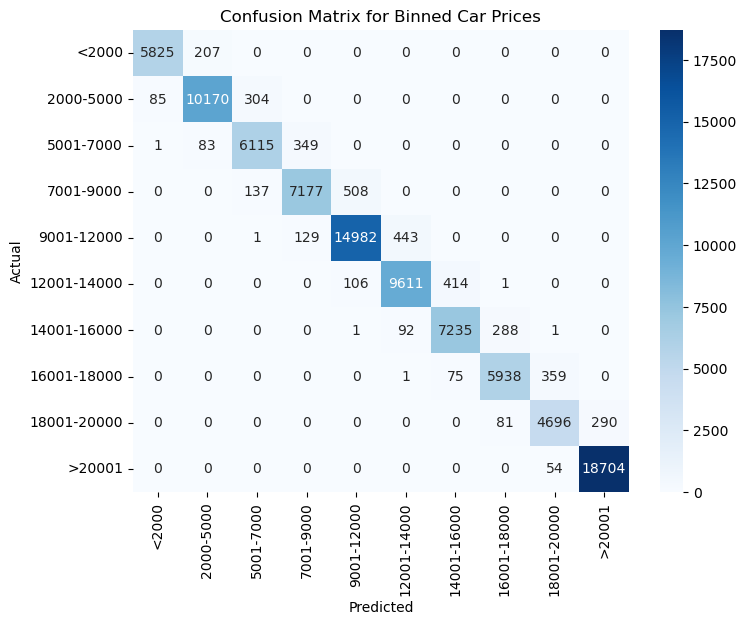

In [25]:
# Bin prices
bins = [0, 2000, 5000, 7000,9000,12000,14000,16000,18000,20000,  np.inf]  # Low (<15k), Medium (15-25k), High (>25k)
labels = ['<2000','2000-5000', '5001-7000', '7001-9000', '9001-12000','12001-14000', '14001-16000', '16001-18000', '18001-20000', '>20001']

# Predict
y_pred_continuous = model.predict(X_test)
y_pred_binned = pd.cut(y_pred_continuous, bins=bins, labels=labels, include_lowest=True)

# Bin y_test for comparison
y_test_binned = pd.cut(y_test_continuous, bins=bins, labels=labels, include_lowest=True)

# Convert binned series to string type to handle potential NaN values and ensure consistent types for confusion_matrix
y_test_binned_str = y_test_binned.astype(str)
y_pred_binned_str = y_pred_binned.astype(str)

# Confusion Matrix
cm = confusion_matrix(y_test_binned_str, y_pred_binned_str, labels=labels)
print("Confusion Matrix:\n", cm)

# Report
print("\nClassification Report:\n", classification_report(y_test_binned_str, y_pred_binned_str))

# Plot (as in notebook)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix for Binned Car Prices')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [26]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Restore original continuous y_train and y_test from the global 'y' using the split indices
y_train_continuous = y.loc[X_train.index]
y_test_continuous = y.loc[X_test.index]

# Metrics
train_mae = mean_absolute_error(y_train_continuous, y_train_pred)
test_mae = mean_absolute_error(y_test_continuous, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_continuous, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_continuous, y_test_pred))

print(f"Train MAE: ${train_mae:.0f} | Test MAE: ${test_mae:.0f} | Gap: {((train_mae - test_mae) / test_mae * 100):+.1f}%")
print(f"Train RMSE: ${train_rmse:.0f} | Test RMSE: ${test_rmse:.0f} | Gap: {((train_rmse - test_rmse) / test_rmse * 100):+.1f}%")

# Threshold: If test/train ratio <0.85 (test 15% worse), overfitting likely
if test_rmse / train_rmse < 0.85:
    print("⚠️ Potential Overfitting: Test underperforms train significantly.")
else:
    print("✅ Good Fit: Metrics are comparable.")

Train MAE: $157 | Test MAE: $160 | Gap: -2.2%
Train RMSE: $780 | Test RMSE: $874 | Gap: -10.7%
✅ Good Fit: Metrics are comparable.


In [27]:
# Bin prices
bins = [0, 2000, 5000, 7000,9000,12000,14000,16000,18000,20000,  np.inf]  # Low (<15k), Medium (15-25k), High (>25k)
labels = ['<2000','2000-5000', '5001-7000', '7001-9000', '9001-12000','12001-14000', '14001-16000', '16001-18000', '18001-20000', '>20001']

# Predict
y_pred_continuous = model.predict(X_test)
y_pred_binned = pd.cut(y_pred_continuous, bins=bins, labels=labels, include_lowest=True)

# Bin y_test for comparison
y_test_binned = pd.cut(y_test_continuous, bins=bins, labels=labels, include_lowest=True)

# Confusion Matrix
cm = confusion_matrix(y_test_binned, y_pred_binned, labels=labels)
print("Confusion Matrix:\n", cm)

# Report
print("\nClassification Report:\n", classification_report(y_test_binned, y_pred_binned))

# Plot (as in notebook)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix for Binned Car Prices')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

TypeError: '<' not supported between instances of 'float' and 'str'

In [ ]:
# Evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"\nBaseline MAE on test set: ${mae:.2f}")
print(f"\nRMSE on test set: ${rmse:.2f}")